In [1]:
import joblib

X_train_scaled = joblib.load("X_train_scaled.pkl")
X_val_scaled = joblib.load("X_val_scaled.pkl")
X_test_scaled = joblib.load("X_test_scaled.pkl")

y_train = joblib.load("y_train.pkl")
y_val = joblib.load("y_val.pkl")
y_test = joblib.load("y_test.pkl")

In [3]:
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.66)

def categorize(value):
    if value <= q1:
        return 0
    elif value <= q2:
        return 1
    else:
        return 2

y_train_class = y_train.apply(categorize)
y_val_class = y_val.apply(categorize)
y_test_class = y_test.apply(categorize)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(8,)),     # <-- Proper way
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    X_train_scaled,
    y_train_class,
    validation_data=(X_val_scaled, y_val_class),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6292 - loss: 0.8279 - val_accuracy: 0.7087 - val_loss: 0.6454
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7267 - loss: 0.6357 - val_accuracy: 0.7242 - val_loss: 0.6309
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7358 - loss: 0.6176 - val_accuracy: 0.7242 - val_loss: 0.6153
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7458 - loss: 0.6048 - val_accuracy: 0.7326 - val_loss: 0.6118
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7470 - loss: 0.5741 - val_accuracy: 0.7345 - val_loss: 0.5977
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7485 - loss: 0.5644 - val_accuracy: 0.7364 - val_loss: 0.5956
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7500 - loss: 0.5749 - val_accuracy: 0.7361 - val_loss: 0.5853
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7519 - loss: 0.5704 - val_accu

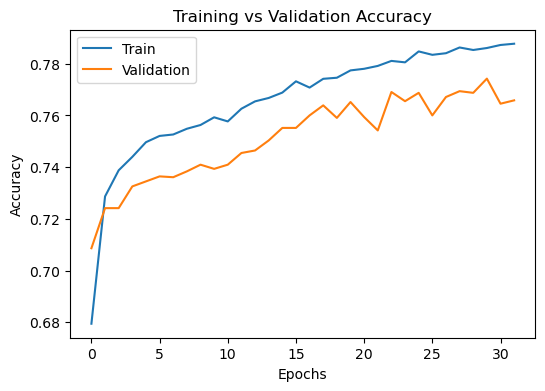

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

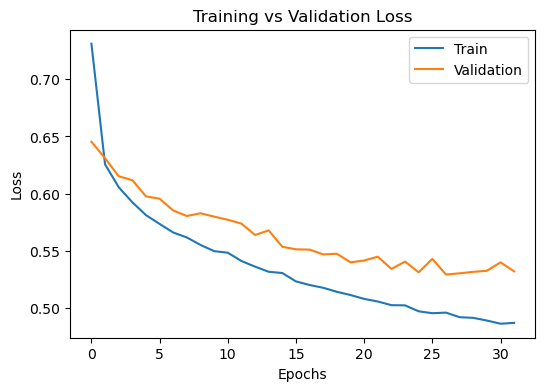

In [21]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_class)

print("Test Accuracy (Neural Network):", test_accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3421 - loss: 1.1600
Test Accuracy (Neural Network): 0.34528422355651855


97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[ 107  813  100]
 [  32  938   39]
 [  17 1026   24]]
              precision    recall  f1-score   support

           0       0.69      0.10      0.18      1020
           1       0.34      0.93      0.50      1009
           2       0.15      0.02      0.04      1067

    accuracy                           0.35      3096
   macro avg       0.39      0.35      0.24      3096
weighted avg       0.39      0.35      0.23      3096



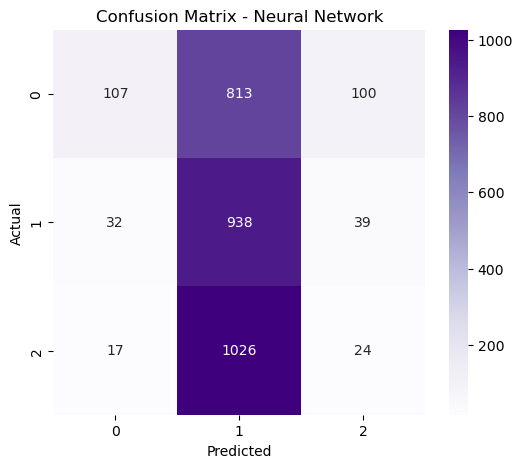

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

y_pred_nn = np.argmax(model.predict(X_test_scaled), axis=1)

print(confusion_matrix(y_test_class, y_pred_nn))
print(classification_report(y_test_class, y_pred_nn))

cm = confusion_matrix(y_test_class, y_pred_nn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()